In [ ]:
# Employee Attrition Prediction using Machine Learning

### Internship Project - Week 2

#Objective:
#Build a machine learning model to predict whether an employee is likely to leave the company based on HR-related features.

In [1]:
# Import all required libraries for data analysis, visualization, preprocessing, and machine learning.

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

# Set visualization style.
plt.style.use("ggplot")
sns.set(font_scale=1.1)

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# Read the uploaded CSV file into a Pandas DataFrame.
#TASK 1
df = pd.read_csv("IBM HR Analytics Employee Attrition & Performance dataset.zip")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
# Display the first 10 records to understand the dataset.

df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
# Display dataset structure, data types, and non-null values.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
# Display the total number of rows and columns.

print("Shape of Dataset:", df.shape)

print("\nNumber of Rows :", df.shape[0])

print("Number of Columns :", df.shape[1])

Shape of Dataset: (1470, 35)

Number of Rows : 1470
Number of Columns : 35


In [7]:
# Display all column names present in the dataset.

print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [8]:
# Display the distribution of the target variable (Attrition).

print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [9]:
# Calculate the percentage of employees who left the company.

attrition_rate = (
    df["Attrition"]
    .value_counts(normalize=True)
    * 100
)

print(attrition_rate)

print(f"\nOverall Attrition Rate : {attrition_rate['Yes']:.2f}%")

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

Overall Attrition Rate : 16.12%


In [10]:
# Separate numeric and categorical columns.

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Number of Numeric Features :", len(numeric_columns))

print("Number of Categorical Features :", len(categorical_columns))

Number of Numeric Features : 26
Number of Categorical Features : 9


In [14]:
#TASK 2
# Check for missing values in each column.

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal Missing Values :", missing_values.sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

Total Missing Values : 0


In [12]:
# Remove columns that do not contribute to prediction.

columns_to_remove = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df.drop(columns=columns_to_remove, inplace=True)

print("Irrelevant columns removed successfully.")

print("\nNew Shape :", df.shape)

Irrelevant columns removed successfully.

New Shape : (1470, 31)


- The dataset is imbalanced, so class imbalance handling will be required during model training.
- No missing values are present in the dataset.

In [15]:
# Convert the target variable 'Attrition' from Yes/No to 1/0.

df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

# Display the converted target values.
print(df["Attrition"].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [16]:
# Separate independent features (X) and target variable (y).

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (1470, 30)
Target Variable Shape: (1470,)


In [17]:
# Identify numerical and categorical columns.

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [18]:
# Apply One-Hot Encoding to all categorical features.

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

print("Shape after One-Hot Encoding:", X_encoded.shape)

X_encoded.head()

Shape after One-Hot Encoding: (1470, 44)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


In [19]:
# Scale numerical features using StandardScaler.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_encoded[numeric_features] = scaler.fit_transform(
    X_encoded[numeric_features]
)

print("Numerical features scaled successfully.")

X_encoded.head()

Numerical features scaled successfully.


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,False,False,False,False,True,False,False,True,False,False
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,True,False,False,False,False,False,False,False,True,True
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,False,False,False,False,True,False,False,True,False,True
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,True,False,False,False,False,False,False,True,False,False


In [21]:
#TASK 3
# Calculate attrition rate by department.

department_attrition = (
    df.groupby("Department")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

print(department_attrition)

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


In [22]:
# Calculate attrition rate by department.

department_attrition = (
    df.groupby("Department")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

print(department_attrition)

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


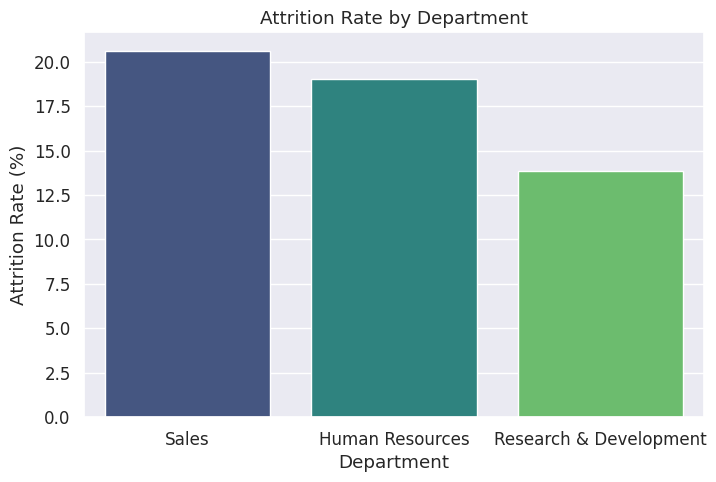

In [23]:
# Plot attrition rate by department.

plt.figure(figsize=(8,5))

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values,
    palette="viridis"
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [24]:
# Calculate attrition rate by job role.

jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

print(jobrole_attrition)

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


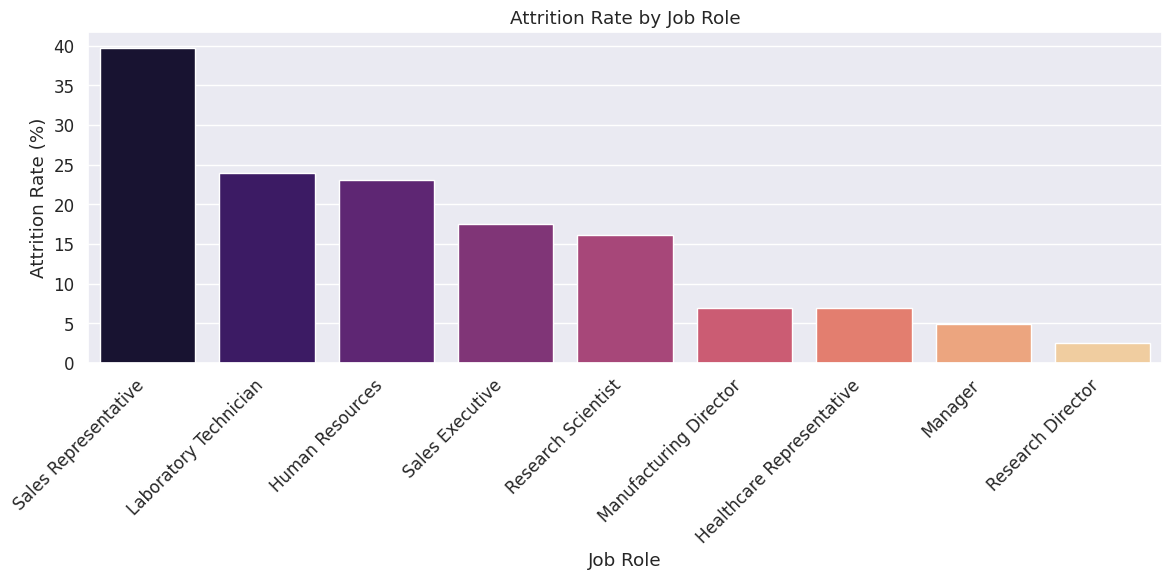

In [25]:
# Plot attrition rate by job role.

plt.figure(figsize=(12,6))

sns.barplot(
    x=jobrole_attrition.index,
    y=jobrole_attrition.values,
    palette="magma"
)

plt.xticks(rotation=45, ha="right")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.show()

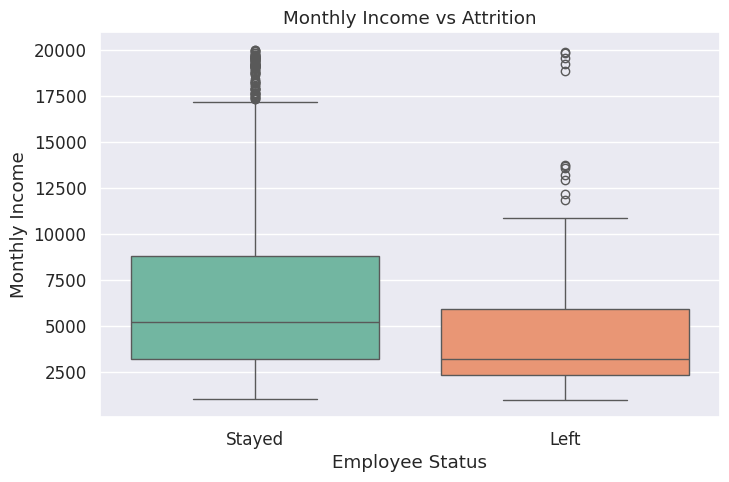

In [26]:
# Compare monthly income of employees who stayed vs left.

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome",
    palette="Set2"
)

plt.xticks([0,1],["Stayed","Left"])

plt.title("Monthly Income vs Attrition")

plt.xlabel("Employee Status")

plt.ylabel("Monthly Income")

plt.show()

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


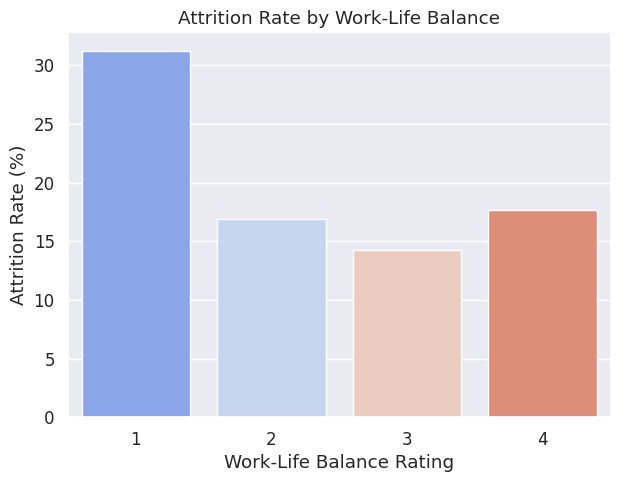

In [27]:
# Analyze attrition across work-life balance ratings.

worklife_attrition = (
    df.groupby("WorkLifeBalance")["Attrition"]
    .mean() * 100
)

print(worklife_attrition)

plt.figure(figsize=(7,5))

sns.barplot(
    x=worklife_attrition.index,
    y=worklife_attrition.values,
    palette="coolwarm"
)

plt.title("Attrition Rate by Work-Life Balance")

plt.xlabel("Work-Life Balance Rating")

plt.ylabel("Attrition Rate (%)")

plt.show()

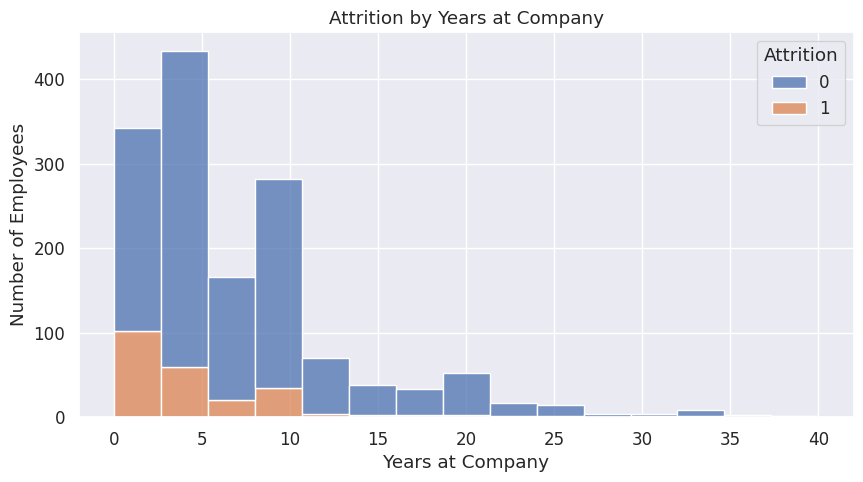

In [28]:
# Visualize employee tenure against attrition.

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack",
    bins=15
)

plt.title("Attrition by Years at Company")

plt.xlabel("Years at Company")

plt.ylabel("Number of Employees")

plt.show()

In [29]:
# Compare average years at company for employees who stayed and left.

df.groupby("Attrition")["YearsAtCompany"].mean()

,YearsAtCompany
Attrition,
0,7.369019
1,5.130802


## Business Insights

1. The Sales department has the highest attrition rate (approximately 20%), indicating that employees in this department leave more frequently than those in Research & Development and Human Resources.

2. Sales Representatives and Laboratory Technicians experience the highest employee exit rates, making them the highest-risk job roles for attrition.

3. Employees who leave the company generally have a lower monthly income than employees who stay, suggesting that compensation may influence retention.

4. Employees with lower Work-Life Balance ratings (1 or 2) show noticeably higher attrition compared to employees with better work-life balance ratings.

5. Most employees leave within their first five years at the company, indicating that early-career employees are at a greater risk of leaving.

In [30]:
#TASK 4
# Split the dataset into 80% training data and 20% testing data.

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set Shape :", X_train.shape)
print("Testing Set Shape :", X_test.shape)

Training Set Shape : (1176, 44)
Testing Set Shape : (294, 44)


In [31]:
# Train the Logistic Regression model using balanced class weights.

lr_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [32]:
# Train the Random Forest Classifier using balanced class weights.

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [33]:
# Train the Gradient Boosting Classifier.

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [34]:
# Generate predictions for all three models.

lr_pred = lr_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

gb_pred = gb_model.predict(X_test)

In [35]:
# Compare the performance of all three models using Accuracy, Precision, Recall, and F1-Score.

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],

    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],

    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ]
})

comparison = comparison.round(3)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.755,0.356,0.660,0.463
1,Random Forest,0.844,0.571,0.085,0.148
2,Gradient Boosting,0.850,0.588,0.213,0.312


In [36]:
# Identify the best-performing model based on the F1 Score.

best_model = comparison.sort_values(
    by="F1 Score",
    ascending=False
)

best_model.head(1)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.755,0.356,0.66,0.463


In [37]:
#TASK 5

In [38]:
# Import evaluation metrics.

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

In [41]:
# Evaluate Logistic Regression model.

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

print("== Logistic Regression ==\n")

print(classification_report(y_test, lr_pred))

print("ROC-AUC Score:",
      round(roc_auc_score(y_test, lr_prob),3))

== Logistic Regression ==

              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294

ROC-AUC Score: 0.804


In [40]:
# Evaluate Random Forest model.

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

print("== Random Forest ==\n")

print(classification_report(y_test, rf_pred))

print("ROC-AUC Score:",
      round(roc_auc_score(y_test, rf_prob),3))

== Random Forest ==

              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

ROC-AUC Score: 0.772


In [42]:
# Evaluate Gradient Boosting model.

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:,1]

print("== Gradient Boosting ==\n")

print(classification_report(y_test, gb_pred))

print("ROC-AUC Score:",
      round(roc_auc_score(y_test, gb_prob),3))

== Gradient Boosting ==

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294

ROC-AUC Score: 0.794


In [43]:
# Create a comparison table using evaluation metrics.

evaluation = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,gb_pred)
    ],

    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,gb_pred)
    ],

    "F1 Score":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,gb_pred)
    ],

    "ROC-AUC":[
        roc_auc_score(y_test,lr_prob),
        roc_auc_score(y_test,rf_prob),
        roc_auc_score(y_test,gb_prob)
    ]

})

evaluation.round(3)

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.356,0.660,0.463,0.804
1,Random Forest,0.571,0.085,0.148,0.772
2,Gradient Boosting,0.588,0.213,0.312,0.794


In [54]:
# Extract feature importance using Logistic Regression coefficients.

lr_importance = pd.DataFrame({

    "Feature": X_encoded.columns,

    "Importance": abs(lr_model.coef_[0])

})

lr_importance = lr_importance.sort_values(
    by="Importance",
    ascending=False
)

lr_importance.head(10)

,Feature,Importance
43,OverTime_Yes,1.626169
23,BusinessTravel_Travel_Frequently,1.596964
34,JobRole_Laboratory Technician,1.571637
40,JobRole_Sales Representative,1.264294
37,JobRole_Research Director,1.112054
30,EducationField_Other,1.020279
24,BusinessTravel_Travel_Rarely,0.903722
42,MaritalStatus_Single,0.864502
33,JobRole_Human Resources,0.670991
16,TotalWorkingYears,0.612480


In [55]:
# Display the top 10 features driving employee attrition.

top10_features = lr_importance.head(10)

top10_features.reset_index(drop=True)

,Feature,Importance
0,OverTime_Yes,1.626169
1,BusinessTravel_Travel_Frequently,1.596964
2,JobRole_Laboratory Technician,1.571637
3,JobRole_Sales Representative,1.264294
4,JobRole_Research Director,1.112054
5,EducationField_Other,1.020279
6,BusinessTravel_Travel_Rarely,0.903722
7,MaritalStatus_Single,0.864502
8,JobRole_Human Resources,0.670991
9,TotalWorkingYears,0.612480


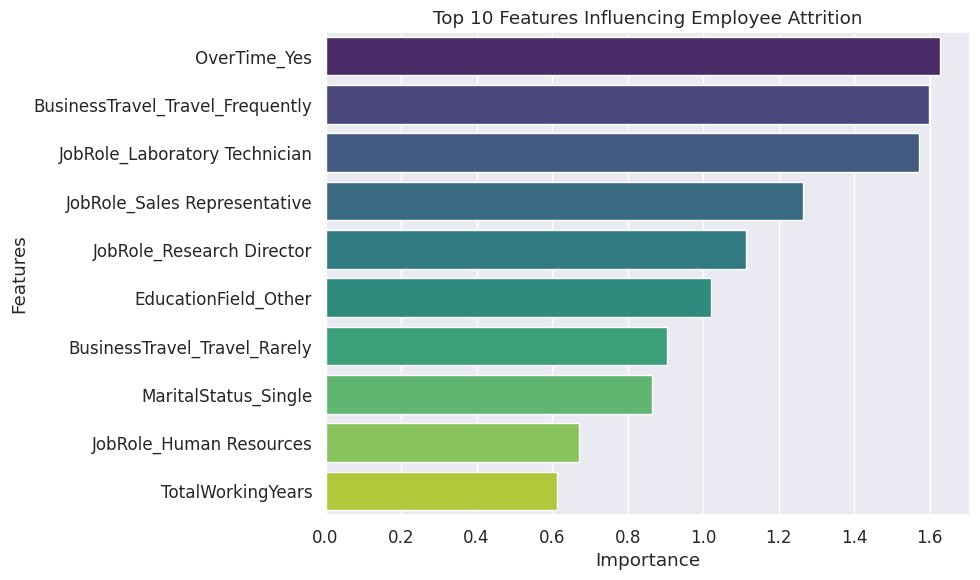

In [56]:
# Plot the top 10 important features.

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_features,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Features Influencing Employee Attrition")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.tight_layout()

plt.show()

## Best Model

Among the three models, Logistic Regression performed the best.

It achieved the highest F1-score (0.463) and the highest ROC-AUC score (0.804). Since the dataset is imbalanced, F1-score is a more appropriate evaluation metric than accuracy because it balances precision and recall. Therefore, Logistic Regression was selected as the final model for predicting employee attrition.

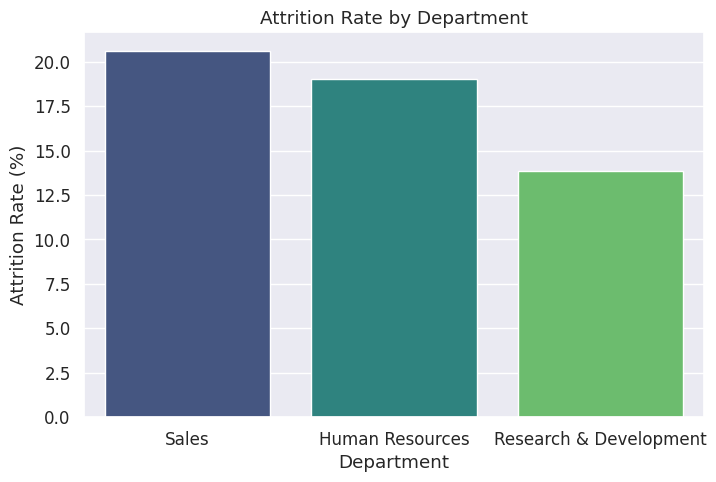

In [57]:
#TASK 6
# Plot attrition rate by department.

department_attrition = (
    df.groupby("Department")["Attrition"]
    .mean()*100
).sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values,
    palette="viridis"
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.show()

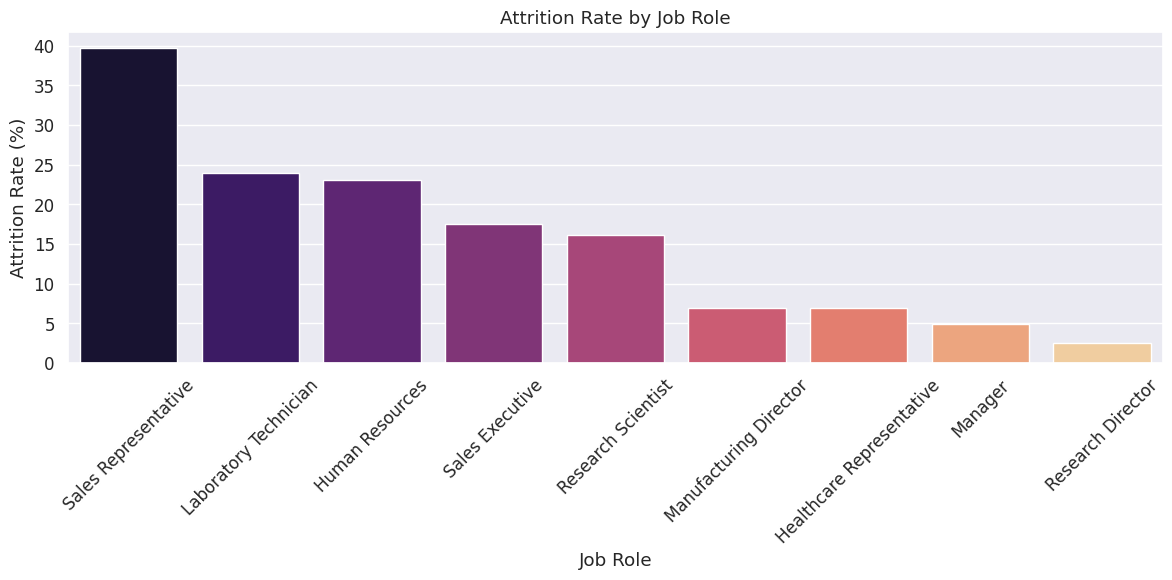

In [58]:
# Plot attrition rate by job role.

jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
    .mean()*100
).sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=jobrole_attrition.index,
    y=jobrole_attrition.values,
    palette="magma"
)

plt.xticks(rotation=45)

plt.title("Attrition Rate by Job Role")

plt.xlabel("Job Role")

plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.show()

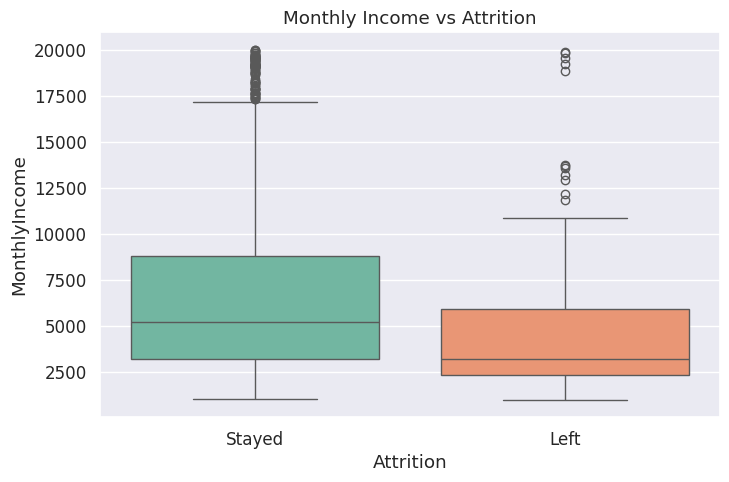

In [59]:
# Compare monthly income of employees who stayed and left.

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome",
    palette="Set2"
)

plt.xticks([0,1],["Stayed","Left"])

plt.title("Monthly Income vs Attrition")

plt.show()

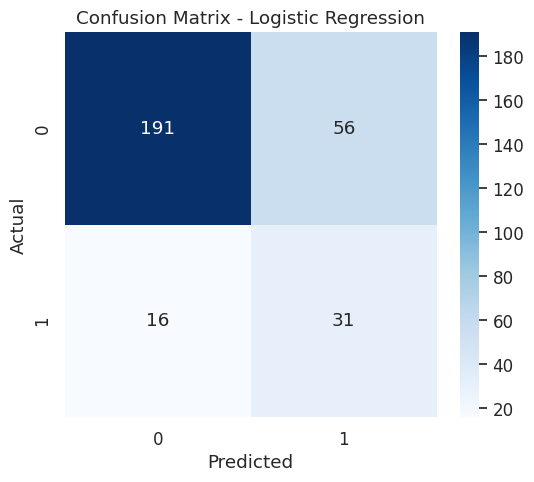

In [60]:
# Display confusion matrix for Logistic Regression.

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

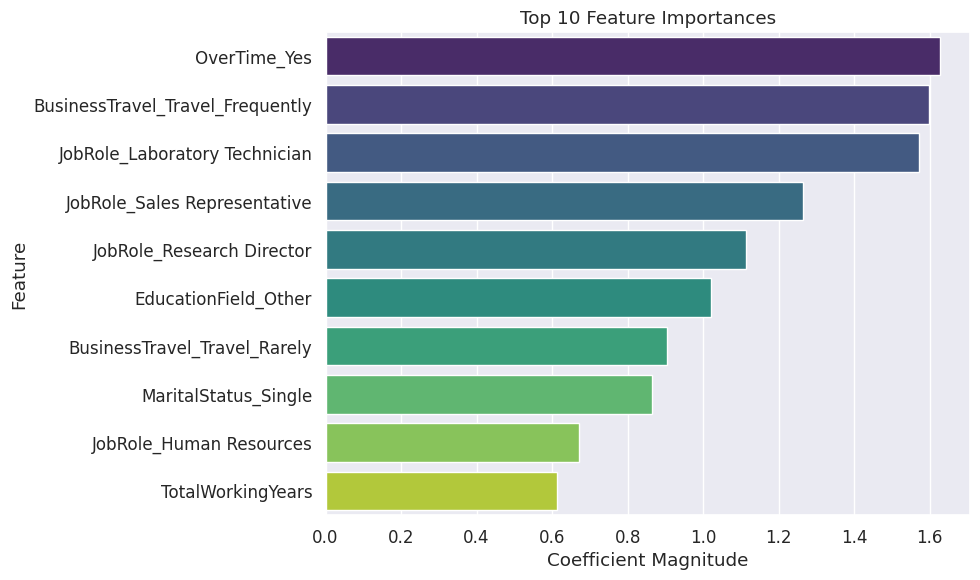

In [61]:
# Plot the top 10 important features.

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_features,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Feature Importances")

plt.xlabel("Coefficient Magnitude")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

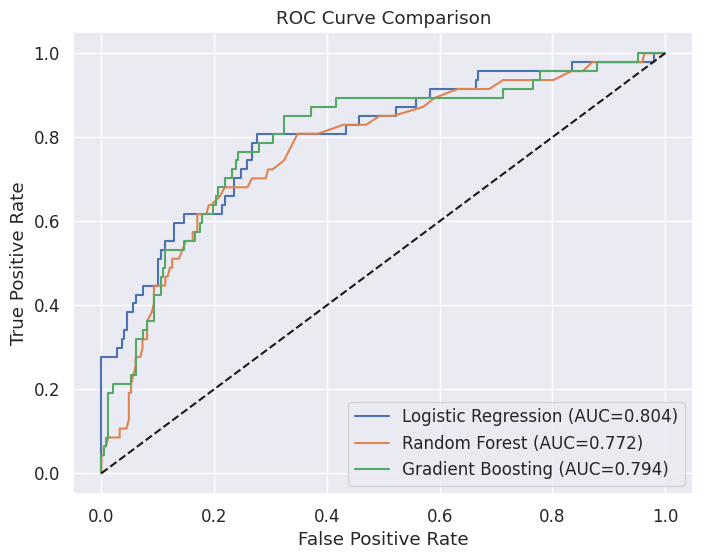

In [62]:
# Plot ROC curves for all three models.

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test, lr_prob):.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f"Gradient Boosting (AUC={roc_auc_score(y_test, gb_prob):.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

TASK 7
## HR Insights & Business Recommendations

1. Which 3 factors most strongly predict that an employee will leave?

Based on the feature importance analysis from the Logistic Regression model, the three strongest factors influencing employee attrition are OverTime, Monthly Income, and Years at Company. Employees who frequently work overtime, earn lower salaries, or have spent fewer years at the company are more likely to leave.

2. Which department or job role should HR prioritize for retention efforts?

The EDA showed that the Sales department has the highest attrition rate. Among job roles, Sales Representatives and Laboratory Technicians experience the highest employee turnover. HR should focus retention efforts on these departments and roles by conducting regular employee engagement and satisfaction surveys.

3. Does salary alone explain attrition?

No. Although employees with lower monthly income tend to leave more often, salary is not the only factor influencing attrition. Work-life balance, overtime, job satisfaction, years at the company, and overall employee experience also play significant roles in an employee's decision to leave.

4. HR Recommendations

- Introduce targeted retention programs for employees in high-risk departments and job roles, especially during their first few years of employment. Regular career development discussions and mentorship programs can improve engagement.
- Monitor employees who frequently work overtime and provide better workload management, flexible working arrangements, and work-life balance initiatives to reduce burnout and improve retention.

5. Model Limitation

This machine learning model predicts the likelihood of employee attrition based only on historical HR data. It cannot capture personal reasons for leaving, such as family commitments, career aspirations, organizational culture, or external job opportunities. Therefore, HR should use this model as a decision-support tool rather than relying on it as the sole basis for employee retention decisions.